# Accumulation

> Batch processing workflow: Sidecar → Aggregate → Visualize

This notebook demonstrates the healpyxel pipeline on batch test data:
1. **Sidecar Creation**: Assign HEALPix cells to geometries
2. **Aggregation**: Compute statistics per HEALPix cell
3. **Densification**: Create complete HEALPix grid
4. **Visualization**: Display the final HEALPix map

## Setup

Import required packages:

In [ ]:
import healpyxel
from healpyxel.sidecar import process_partition
from healpyxel.aggregate import aggregate_by_sidecar, densify_healpix_aggregates
import pandas as pd
import numpy as np
import geopandas as gpd
from pathlib import Path
from shapely import wkb

print(f"healpyxel version: {healpyxel.__version__}")

healpyxel version: 0.1.0


## Test Data Discovery

Find available batch data files:

In [ ]:
# Look for test data
test_data_dir = Path('../test_data')
batches_dir = test_data_dir / 'batches'

if batches_dir.exists():
    batch_files = sorted(batches_dir.glob('batch_*.parquet'))
    print(f"Found {len(batch_files)} batch files!")
    print(f"\nFirst few batches:")
    for f in batch_files[:5]:
        size_mb = f.stat().st_size / 1024 / 1024
        print(f"  {f.name}: {size_mb:.2f} MB")
    if len(batch_files) > 5:
        print(f"  ... and {len(batch_files) - 5} more")
else:
    print("Batch data not found. Run create_test_data.sh to generate test data.")
    batch_files = []

Found 10 batch files!

First few batches:
  batch_001.parquet: 1.12 MB
  batch_002.parquet: 1.51 MB
  batch_003.parquet: 1.37 MB
  batch_004.parquet: 1.46 MB
  batch_005.parquet: 1.66 MB
  ... and 5 more


## Step 1: Create Sidecar for Each Batch

Process each batch file to create HEALPix assignments:

In [ ]:
#| eval: false
# Configuration
nside = 64  # HEALPix resolution
mode = 'fuzzy'  # Assignment mode
lon_convention = '0_360'  # Longitude range of input data

# Process first few batches as demonstration (adjust as needed)
n_batches_to_process = min(3, len(batch_files)) if batch_files else 0

sidecars = []
for i, batch_file in enumerate(batch_files[:n_batches_to_process]):
    print(f"\n[{i+1}/{n_batches_to_process}] Processing {batch_file.name}...")
    
    # Load batch data
    df = pd.read_parquet(batch_file)
    
    # Convert WKB geometry to GeoDataFrame
    if 'geometry' in df.columns:
        df['geometry'] = df['geometry'].apply(lambda x: wkb.loads(bytes(x)) if x is not None else None)
        gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
    else:
        print(f"  ⚠️  No geometry column found, skipping...")
        continue
    
    # Create sidecar
    sidecar = process_partition(
        gdf=gdf,
        nside=nside,
        mode=mode,
        base_index=0,
        lon_convention=lon_convention  # Use lon_convention instead of lat_min/lat_max
    )
    
    # Store with batch info
    sidecar['batch'] = i
    sidecars.append(sidecar)
    
    print(f"  ✓ Created {len(sidecar)} assignments from {len(gdf)} geometries")
    print(f"    Unique cells: {sidecar['healpix_id'].nunique()}")

#| eval: false
if sidecars:
    # Combine all sidecars
    combined_sidecar = pd.concat(sidecars, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Combined sidecar: {len(combined_sidecar)} total assignments")
    print(f"Unique cells touched: {combined_sidecar['healpix_id'].nunique()}")
    print(f"Unique sources: {combined_sidecar['source_id'].nunique()}")
else:
    print("\nNo sidecars created. Check that batch files exist and have geometry columns.")


[1/3] Processing batch_001.parquet...


2025-12-11 15:11:05,333 INFO Partition: processed 3029 geometries, dropped 2 (0.1%) due to invalid bounds


  ✓ Created 3912 assignments from 3029 geometries
    Unique cells: 341

[2/3] Processing batch_002.parquet...


2025-12-11 15:11:06,269 INFO Partition: processed 4127 geometries, dropped 3 (0.1%) due to invalid bounds


  ✓ Created 5382 assignments from 4127 geometries
    Unique cells: 338

[3/3] Processing batch_003.parquet...
  ✓ Created 4892 assignments from 3734 geometries
    Unique cells: 342

Combined sidecar: 14186 total assignments
Unique cells touched: 641
Unique sources: 4127
  ✓ Created 4892 assignments from 3734 geometries
    Unique cells: 342

Combined sidecar: 14186 total assignments
Unique cells touched: 641
Unique sources: 4127


## Step 2: Aggregate Data by HEALPix Cells

Now aggregate the original data values by HEALPix cell using the sidecar:

In [ ]:
#| eval: false
# Reload and combine data from processed batches (drop geometry for aggregation)
combined_data_list = []

for i, batch_file in enumerate(batch_files[:n_batches_to_process]):
    df = pd.read_parquet(batch_file)
    
    # Drop geometry column if present (not needed for aggregation)
    if 'geometry' in df.columns:
        df = df.drop(columns=['geometry'])
    
    # Add source_id matching the sidecar creation
    df['source_id'] = df.index.astype(np.int64)
    df['batch'] = i
    combined_data_list.append(df)

if combined_data_list:
    combined_data = pd.concat(combined_data_list, ignore_index=True)
    print(f"Combined data: {len(combined_data)} rows")
    print(f"Columns: {list(combined_data.columns)}")
    print(f"\nFirst few rows:")
    display(combined_data.head())

Combined data: 10890 rows
Columns: ['ref_id', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q1', 'q2', 'q3', 'q4', 'obs_id', 'vis_slope', 'nir_slope', 'visnir_slope', 'norm_vis_slope', 'norm_nir_slope', 'norm_visnir_slope', 'curvature', 'norm_curvature', 'uv_downturn', 'color_index_310_390', 'color_index_415_750', 'color_index_750_415', 'color_index_750_950', 'r310', 'r390', 'r750', 'r950', 'r1050', 'r1400', 'r415', 'r433_2', 'r479_9', 'r556_9', 'r628_8', 'r748_7', 'r828_4', 'r898_8', 'r996_2', 'spot_number', 'lat_center', 'lon_center', 'surface', 'width', 'length', 'ang_incidence', 'ang_emission', 'ang_phase', 'azimuth', 'source_id', 'batch']

First few rows:


,ref_id,a,b,c,d,e,f,g,h,i,...,lon_center,surface,width,length,ang_incidence,ang_emission,ang_phase,azimuth,source_id,batch
0,0801419125400568,0,0,0,0,0,1,0,0,0,...,175.06512,54194396.0,5599.9224,12322.036,9.834717,73.333954,83.013830,154.51570,0,0
1,0801419125400569,0,0,0,0,0,1,0,0,0,...,175.14010,54753300.0,5660.6910,12315.469,9.769003,73.381120,82.985110,154.42958,1,0
2,0801419125400570,0,0,0,0,0,1,0,0,0,...,175.21364,54823684.0,5736.7520,12167.806,9.704690,73.427300,82.956314,154.33447,2,0
3,0801419125400571,0,0,0,0,0,1,0,0,0,...,175.28458,54962964.0,5861.2773,11939.551,9.641157,73.473150,82.927510,154.23120,3,0
4,0801419125400572,0,0,0,0,0,1,0,0,0,...,175.35536,55392168.0,5779.1610,12203.761,9.577167,73.520050,82.898830,154.12103,4,0


In [ ]:
#| eval: false
# Choose a value column to aggregate (adjust based on your data)
# Common columns in MESSENGER MASCS data: r1050, r750, etc.
value_columns = ['r1050'] if 'r1050' in combined_data.columns else []

if not value_columns:
    # Try to find numeric columns
    numeric_cols = combined_data.select_dtypes(include=[np.number]).columns.tolist()
    # Exclude id and coordinate columns
    exclude = ['source_id', 'batch', 'lat_center', 'lon_center', 'lat', 'lon', 'latitude', 'longitude']
    value_columns = [c for c in numeric_cols if c not in exclude][:1]  # Take first suitable column

print(f"Aggregating column(s): {value_columns}")

if value_columns and sidecars:
    # Perform aggregation
    aggregated = aggregate_by_sidecar(
        original=combined_data,
        sidecar=combined_sidecar,
        value_columns=value_columns,
        aggs=['mean', 'median', 'std', 'mad', 'robust_std'],
        source_id_col='source_id',
        healpix_col='healpix_id',
        min_count=1,
        include_counts=True,
        sentinel_threshold=1e30
    )
    
    print(f"\nAggregated {len(aggregated)} HEALPix cells")
    print(f"Columns: {list(aggregated.columns)}")
    display(aggregated.head(10))
else:
    print("Cannot aggregate: no suitable value columns or no sidecars created")

2025-12-11 15:11:07,204 INFO Starting aggregation for 1 column(s): ['r1050']
2025-12-11 15:11:07,205 INFO Aggregation functions: ['mean', 'median', 'std', 'mad', 'robust_std']
2025-12-11 15:11:07,205 INFO Aggregation functions: ['mean', 'median', 'std', 'mad', 'robust_std']
2025-12-11 15:11:07,218 WARNING Found 6763 duplicate source_id values - keeping first occurrence
2025-12-11 15:11:07,218 WARNING Found 6763 duplicate source_id values - keeping first occurrence


Aggregating column(s): ['r1050']


2025-12-11 15:11:07,228 INFO Sidecar source_id overlap: 4127/4127 (100.0%)
2025-12-11 15:11:07,229 INFO Merging sidecar with original data
2025-12-11 15:11:07,229 INFO Merging sidecar with original data
2025-12-11 15:11:07,233 INFO Grouping by healpix_id and computing aggregations
2025-12-11 15:11:07,241 INFO Processing 641 HEALPix cells
2025-12-11 15:11:07,233 INFO Grouping by healpix_id and computing aggregations
2025-12-11 15:11:07,241 INFO Processing 641 HEALPix cells


Aggregating HEALPix cells:   0%|          | 0/641 [00:00<?, ?cell/s]

2025-12-11 15:11:07,456 INFO Creating output DataFrame with 641 cells
2025-12-11 15:11:07,459 INFO Aggregation complete. Output shape: (641, 6)
2025-12-11 15:11:07,459 INFO Aggregation complete. Output shape: (641, 6)



Aggregated 641 HEALPix cells
Columns: ['r1050_mean', 'r1050_median', 'r1050_std', 'r1050_mad', 'r1050_robust_std', 'n_sources']


,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,
5441,0.065725,0.066955,0.001959,0.000304,0.000451,3
5443,0.062025,0.062025,0.000000,0.000000,0.000000,1
5444,0.052158,0.050539,0.005063,0.002227,0.003301,10
5445,0.055384,0.053641,0.008371,0.005352,0.007935,49
5447,0.062666,0.066012,0.007553,0.003986,0.005910,11
5456,0.055859,0.052784,0.008179,0.004984,0.007389,37
5457,0.054064,0.051851,0.006374,0.004704,0.006975,12
5458,0.055457,0.052863,0.012101,0.011351,0.016828,36
5459,0.048873,0.049093,0.009073,0.006335,0.009392,40


## Step 3: Densify for Complete HEALPix Grid

Fill in empty cells to create a complete HEALPix map:

In [ ]:
#| eval: false
if value_columns and sidecars:
    # Densify the sparse aggregated data
    aggregated_dense = densify_healpix_aggregates(
        agg_sparse_df=aggregated,
        nside=nside,
        index_name='healpix_id'
    )
    
    total_cells = 12 * nside ** 2
    filled_cells = aggregated[f'{value_columns[0]}_mean'].notna().sum()
    empty_cells = total_cells - filled_cells
    
    print(f"HEALPix Grid (nside={nside}):")
    print(f"  Total cells: {total_cells}")
    print(f"  Cells with data: {filled_cells}")
    print(f"  Empty cells: {empty_cells}")
    print(f"  Coverage: {100 * filled_cells / total_cells:.2f}%")
    
    display(aggregated_dense.head(10))

2025-12-11 15:11:07,511 INFO Densified to 49152 cells (added 48511 empty cells)


HEALPix Grid (nside=64):
  Total cells: 49152
  Cells with data: 641
  Empty cells: 48511
  Coverage: 1.30%


,r1050_mean,r1050_median,r1050_std,r1050_mad,r1050_robust_std,n_sources
healpix_id,,,,,,
0,NaN,NaN,NaN,NaN,NaN,<NA>
1,NaN,NaN,NaN,NaN,NaN,<NA>
2,NaN,NaN,NaN,NaN,NaN,<NA>
3,NaN,NaN,NaN,NaN,NaN,<NA>
4,NaN,NaN,NaN,NaN,NaN,<NA>
5,NaN,NaN,NaN,NaN,NaN,<NA>
6,NaN,NaN,NaN,NaN,NaN,<NA>
7,NaN,NaN,NaN,NaN,NaN,<NA>
8,NaN,NaN,NaN,NaN,NaN,<NA>


## Step 4: Visualize HEALPix Map

Create a visualization of the aggregated data:

2025-12-11 15:11:07,965 INFO 0.0 180.0 -180.0 180.0
2025-12-11 15:11:07,966 INFO The interval between parallels is 30 deg -0.00'.
2025-12-11 15:11:07,967 INFO The interval between meridians is 30 deg -0.00'.
2025-12-11 15:11:07,966 INFO The interval between parallels is 30 deg -0.00'.
2025-12-11 15:11:07,967 INFO The interval between meridians is 30 deg -0.00'.


<Figure size 1200x800 with 0 Axes>

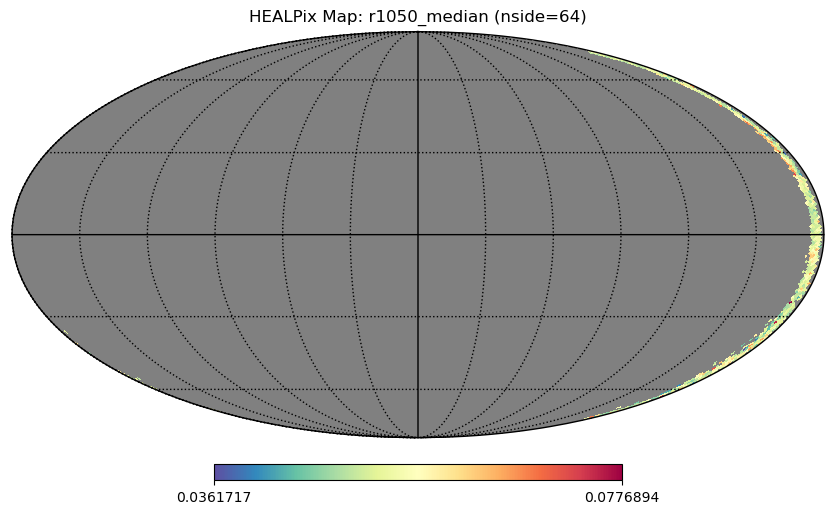


Map Statistics:
  Min: 0.0362
  Max: 0.0777
  Mean: 0.0535
  Median: 0.0527


In [ ]:
#| eval: false
if value_columns and sidecars:
    import healpy as hp
    import matplotlib.pyplot as plt
    
    # Choose which statistic to visualize
    stat_column = f'{value_columns[0]}_median'
    
    # Extract map values (NaN for empty cells)
    healpix_map = aggregated_dense[stat_column].values.astype(float)
    
    # Create visualization
    plt.figure(figsize=(12, 8))
    hp.mollview(
        healpix_map,
        nest=True,
        title=f'HEALPix Map: {stat_column} (nside={nside})',
        cmap='Spectral_r',
        flip='geo',
        xsize=2000
    )
    hp.graticule()
    plt.show()
    
    # Statistics of the mapped data
    valid_data = healpix_map[~np.isnan(healpix_map)]
    print(f"\nMap Statistics:")
    print(f"  Min: {valid_data.min():.4f}")
    print(f"  Max: {valid_data.max():.4f}")
    print(f"  Mean: {valid_data.mean():.4f}")
    print(f"  Median: {np.median(valid_data):.4f}")

## Summary

This notebook demonstrated the complete healpyxel workflow:

1. **Sidecar Creation**: Assigned HEALPix cells to geometries using `process_partition()`
2. **Aggregation**: Computed statistics per cell using `aggregate_by_sidecar()`
3. **Densification**: Created complete grid using `densify_healpix_aggregates()`
4. **Visualization**: Displayed the final HEALPix map

### For Large Datasets

For processing many batch files efficiently, use the CLI tools:

```bash
# Process all batches with sidecar creation
for batch in test_data/batches/batch_*.parquet; do
    healpix_sidecar --input "$batch" \
                    --nside 32 64 \
                    --mode fuzzy \
                    --lon-convention 0_360 \
                    --ncores 4
done

# Aggregate all data
healpix_aggregate --input test_data/batches/ \
                  --pattern "*.parquet" \
                  --nside 32 \
                  --output aggregated_nside32.parquet

# Finalize maps
healpix_finalize --input aggregated_nside32.parquet \
                 --nside 32 \
                 --output final_maps/
```

### Next Steps

- Experiment with different `nside` values for different resolutions
- Try both 'strict' and 'fuzzy' assignment modes
- Aggregate multiple value columns simultaneously
- Use `finalize_maps()` to create production-ready map products